
# VIP SLAP2 session review notebook

This notebook is organized around three tasks for a single mouse session:

1. Open a `SummaryLoCo*.mat` file, process the whole-session Ca$^{2+}$ data, and visualize it with image presentation times and identities overlaid.
2. Load extracted data and QC outputs for both glutamate and calcium.
3. Display `meanIM` for a chosen DMD.

The notebook assumes you are working inside the `vip-slap2-analysis` environment and have access to the network session directories.


In [1]:

%load_ext autoreload
%autoreload 2
%matplotlib notebook

import json
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PNW_cmap import PNW_cmap
from IPython.display import display, Markdown

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.glutamate.alignment import (
    load_corrected_bonsai_csv,
    load_imaging_epochs_csv,
    extract_image_intervals,
    filter_ordered_images_to_epochs,
)

sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

## Configuration

In [2]:

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SESSION_ID = None  # e.g. "834788_2026-03-04_08-43-07"; leave as None to use SUBJECT_ID + SESSION_INDEX
SUBJECT_ID = 834788
SESSION_INDEX = 1  # used only when SESSION_ID is None

FS_HZ = 200.0
DMD_FOR_CALCIUM = 2
ROI_INDICES_TO_PLOT = [0,1,2]          # whole-session calcium traces
MAX_SESSION_MINUTES = None         # e.g. 10.0 to truncate late-session data
MOTION_CORRECT = True
TRACE_TYPE = "Fsvd"
CALCIUM_TRACE_KEY = "dff"         # one of: dff, ca_mc, ca_unmixed, ca_clean

DMD_FOR_MEANIM = 2
MEANIM_IMAGE_TYPE = "meanIM"
MEANIM_CHANNEL = 0


## Resolve the session asset and open the SummaryLoCo file

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

if SESSION_ID is not None:
    session_row = registry.get_session_row(SESSION_ID)
else:
    subject_sessions = registry.sessions(subject_ids=[SUBJECT_ID]).reset_index(drop=True)
    if len(subject_sessions) == 0:
        raise ValueError(f"No sessions found for subject {SUBJECT_ID}")
    session_row = subject_sessions.iloc[SESSION_INDEX]

asset = registry.resolve_assets(session_row)
asset.ensure_dirs()
exp = GlutamateSummary(asset.summary_mat, keep_open=True)

print(f"session_id: {asset.session_id}")
print(f"subject_id: {asset.subject_id}")
print(f"summary_mat: {asset.summary_mat}")
print(f"bonsai_csv: {asset.bonsai_event_log_csv}")
print(f"qc_dir: {asset.qc_dir}")
print(f"derived_dir: {asset.derived_dir}")

session_id: 834788_2026-03-02_10-18-42
subject_id: 834788
summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-02_10-18-42\834788_2026-03-02_10-18-42_slap2_2026-03-02_10-18-42\source_extraction\ExperimentSummary\SummaryLoCo-260303-084206.mat
bonsai_csv: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-02_10-18-42\834788_2026-03-02_10-18-42\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
qc_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-02_10-18-42\analysis\qc
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-02_10-18-42\analysis\derived


## Helper functions

In [4]:

from matplotlib.patches import Patch


def _load_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)


def _load_npz_object(path):
    path = Path(path)
    if not path.exists():
        return None
    obj = np.load(path, allow_pickle=True)
    if "data" in obj.files:
        return obj["data"].item()
    return {k: obj[k] for k in obj.files}


def load_stimulus_events(asset):
    """Load corrected Bonsai events and optionally filter them to imaging epochs."""
    if asset.bonsai_event_log_csv is None:
        raise FileNotFoundError("No bonsai_event_log_csv found for this asset")

    stim_df = load_corrected_bonsai_csv(asset.bonsai_event_log_csv)
    image_times, ordered_images = extract_image_intervals(stim_df)

    epoch_csv = Path(asset.qc_dir) / "behavior" / "imaging_epochs.csv"
    epoch_df = load_imaging_epochs_csv(epoch_csv) if epoch_csv.exists() else None

    if epoch_df is not None:
        ordered_images = filter_ordered_images_to_epochs(
            ordered_images,
            epoch_df,
            pre_time=0.25,
            post_time=0.50,
        )
        session_start_sec = float(epoch_df.iloc[0]["start_time"])
        session_end_sec = float(epoch_df.iloc[-1]["end_time"])
    else:
        time_col = "corrected_timestamp" if "corrected_timestamp" in stim_df.columns else "corrected_timestamps"
        session_start_sec = float(stim_df[time_col].min())
        session_end_sec = float(stim_df[time_col].max())

    return {
        "stim_df": stim_df,
        "ordered_images": ordered_images,
        "epoch_df": epoch_df,
        "session_start_sec": session_start_sec,
        "session_end_sec": session_end_sec,
    }


def reconstruct_whole_session_calcium(
    exp,
    dmd,
    fs_hz=200.0,
    motion_correct=True,
    trace_type="Fsvd",
    max_session_minutes=None,
):
    """
    Reconstruct whole-session soma calcium arrays from per-trial outputs.
    Returns a dict with traces shaped (n_rois, n_time_session).
    """
    proc = exp.get_processed_soma_ca_all_trials(
        dmd=dmd,
        trace_type=trace_type,
        fs_hz=fs_hz,
        include_invalid=True,
        motion_correct=motion_correct,
        max_session_minutes=max_session_minutes,
    )

    out = {}
    for key in ["dff", "ca_mc", "ca_unmixed", "ca_clean", "baseline"]:
        arr = proc.get(key)
        if arr is None:
            out[key] = None
            continue
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 3:
            raise ValueError(f"Expected {key} to have shape (n_trials, n_rois, n_time), got {arr.shape}")
        out[key] = np.concatenate([arr[tr] for tr in range(arr.shape[0])], axis=1)

    n_time = out["dff"].shape[1] if out["dff"] is not None else 0
    out["time_sec"] = np.arange(n_time) / fs_hz
    out["proc"] = proc
    return out


def plot_whole_session_calcium(
    session_ca,
    ordered_images,
    session_start_sec,
    roi_indices=None,
    trace_key="dff",
    max_image_legend=12,
):
    traces = session_ca[trace_key]
    if traces is None:
        raise ValueError(f"Trace key {trace_key!r} is not available")

    n_rois, n_time = traces.shape
    if roi_indices is None:
        roi_indices = list(range(min(n_rois, 5)))
    roi_indices = [r for r in roi_indices if 0 <= r < n_rois]
    if len(roi_indices) == 0:
        raise ValueError("No valid ROI indices selected")

    time_sec = session_ca["time_sec"]
    fig, (ax_evt, ax) = plt.subplots(
        2,
        1,
        figsize=(18, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]},
        constrained_layout=True,
    )
    
    for axis in [ax_evt,ax]:
        axis.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        axis.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        sns.despine(ax=axis)
        for spine in ['left','bottom']:
            axis.spines[spine].set_linewidth(1.5)
    
    unique_images = sorted({evt.image_name for evt in ordered_images})
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_images), 1)))
    color_map = {img: colors[i % len(colors)] for i, img in enumerate(unique_images)}
    
    cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sailboat',n_colors=len(roi_indices))

    for evt in ordered_images:
        onset_rel = float(evt.onset) - float(session_start_sec)
        ax_evt.axvspan(onset_rel, onset_rel + 0.25, color=color_map[evt.image_name], alpha=0.8)

    legend_handles = [Patch(facecolor=color_map[img], label=img) for img in unique_images[:max_image_legend]]
    legend_labels = [img.split('\\')[-1] for img in unique_images[:max_image_legend]]
    if len(unique_images) > 0:
        ax_evt.legend(handles=legend_handles,labels=legend_labels, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="image")
    ax_evt.set_ylabel("flash")
    ax_evt.set_yticks([])
    ax_evt.set_title("Image presentation times and identities",fontsize=18)

    finite_scale = np.nanpercentile(np.abs(traces[roi_indices]), 99.999999)
    offset = finite_scale if np.isfinite(finite_scale) and finite_scale > 0 else 1.0

    for i, roi in enumerate(roi_indices):
        ax.plot(time_sec, traces[roi] + i * offset, lw=1.5, label=f"ROI {roi}",color = cl[i])
        rolling  = pd.DataFrame(traces[roi]).rolling(25,min_periods=1).mean()
        ax.plot(time_sec, rolling + i * offset,color='k',lw=1)

    ax.set_xlabel("Session time from imaging epoch start (s)")
    ax.set_ylabel(f"{trace_key} (offset)")
    ax.set_title(f"Whole-session calcium traces ({trace_key})")
    ax.legend(frameon=False, ncol=min(4, len(roi_indices)))
    return fig, (ax_evt, ax)


def display_meanim(exp, dmd=1, image_type="meanIM", channel=0, robust=(1, 99)):
    im = exp.get_summary_image(dmd=dmd, image_type=image_type)
    im = np.asarray(im, dtype=float)

    if im.ndim == 3:
        if channel >= im.shape[1]:
            raise ValueError(f"Requested channel {channel}, but image has shape {im.shape}")
        im = im[:, channel, :]
    elif im.ndim != 2:
        raise ValueError(f"Unexpected meanIM shape: {im.shape}")

    im = np.nan_to_num(im, nan=0.0)
    vmin, vmax = np.percentile(im, robust)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(im.T, cmap="viridis", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"DMD{dmd} {image_type}, channel {channel}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return fig, ax


def load_analysis_products(asset):
    qc_dir = Path(asset.qc_dir)
    derived_dir = Path(asset.derived_dir)

    paths = {
        "glutamate_qc_json": qc_dir / "glutamate" / "glutamate_qc.json",
        "glutamate_qc_csv": qc_dir / "glutamate" / "glutamate_qc_table.csv",
        "glutamate_mean_npz": derived_dir / "glutamate" / "glutamate_mean_dff.npz",
        "glutamate_single_npz": derived_dir / "glutamate" / "glutamate_single_trial_dff.npz",
        "glutamate_sequence_npz": derived_dir / "glutamate" / "glutamate_sequence_dff.npz",
        "glutamate_meta_json": qc_dir / "glutamate" / "glutamate_extraction_meta.json",
        "calcium_qc_json": qc_dir / "calcium" / "calcium_qc.json",
        "calcium_qc_csv": qc_dir / "calcium" / "calcium_qc_table.csv",
        "calcium_mean_npz": derived_dir / "calcium" / "calcium_mean_dff.npz",
        "calcium_single_npz": derived_dir / "calcium" / "calcium_single_trial_dff.npz",
        "calcium_sequence_npz": derived_dir / "calcium" / "calcium_sequence_dff.npz",
        "calcium_meta_json": qc_dir / "calcium" / "calcium_extraction_meta.json",
    }

    products = {"paths": paths}
    for key, path in paths.items():
        if key.endswith("_json"):
            products[key] = _load_json(path)
        elif key.endswith("_csv"):
            products[key] = pd.read_csv(path) if path.exists() else None
        elif key.endswith("_npz"):
            products[key] = _load_npz_object(path)
        else:
            products[key] = None
    return products


def summarize_products(products):
    rows = []
    for key, path in products["paths"].items():
        rows.append({
            "product": key,
            "exists": Path(path).exists(),
            "path": str(path),
        })
    return pd.DataFrame(rows)


## 1) Whole-session calcium processing and visualization

In [5]:

stim_info = load_stimulus_events(asset)
print(f"n image flashes after epoch filtering: {len(stim_info['ordered_images'])}")
print(f"epoch start: {stim_info['session_start_sec']:.3f} s")
print(f"epoch end:   {stim_info['session_end_sec']:.3f} s")


n image flashes after epoch filtering: 2356
epoch start: 4.192 s
epoch end:   1804.202 s


In [6]:

whole_session_ca = reconstruct_whole_session_calcium(
    exp,
    dmd=DMD_FOR_CALCIUM,
    fs_hz=FS_HZ,
    motion_correct=MOTION_CORRECT,
    trace_type=TRACE_TYPE,
    max_session_minutes=MAX_SESSION_MINUTES,
)

for key in ["dff", "ca_mc", "ca_unmixed", "ca_clean", "baseline"]:
    arr = whole_session_ca.get(key)
    print(key, None if arr is None else arr.shape)


dff (4, 360035)
ca_mc (4, 360035)
ca_unmixed (4, 360035)
ca_clean (4, 360035)
baseline (4, 360035)


<IPython.core.display.Javascript object>


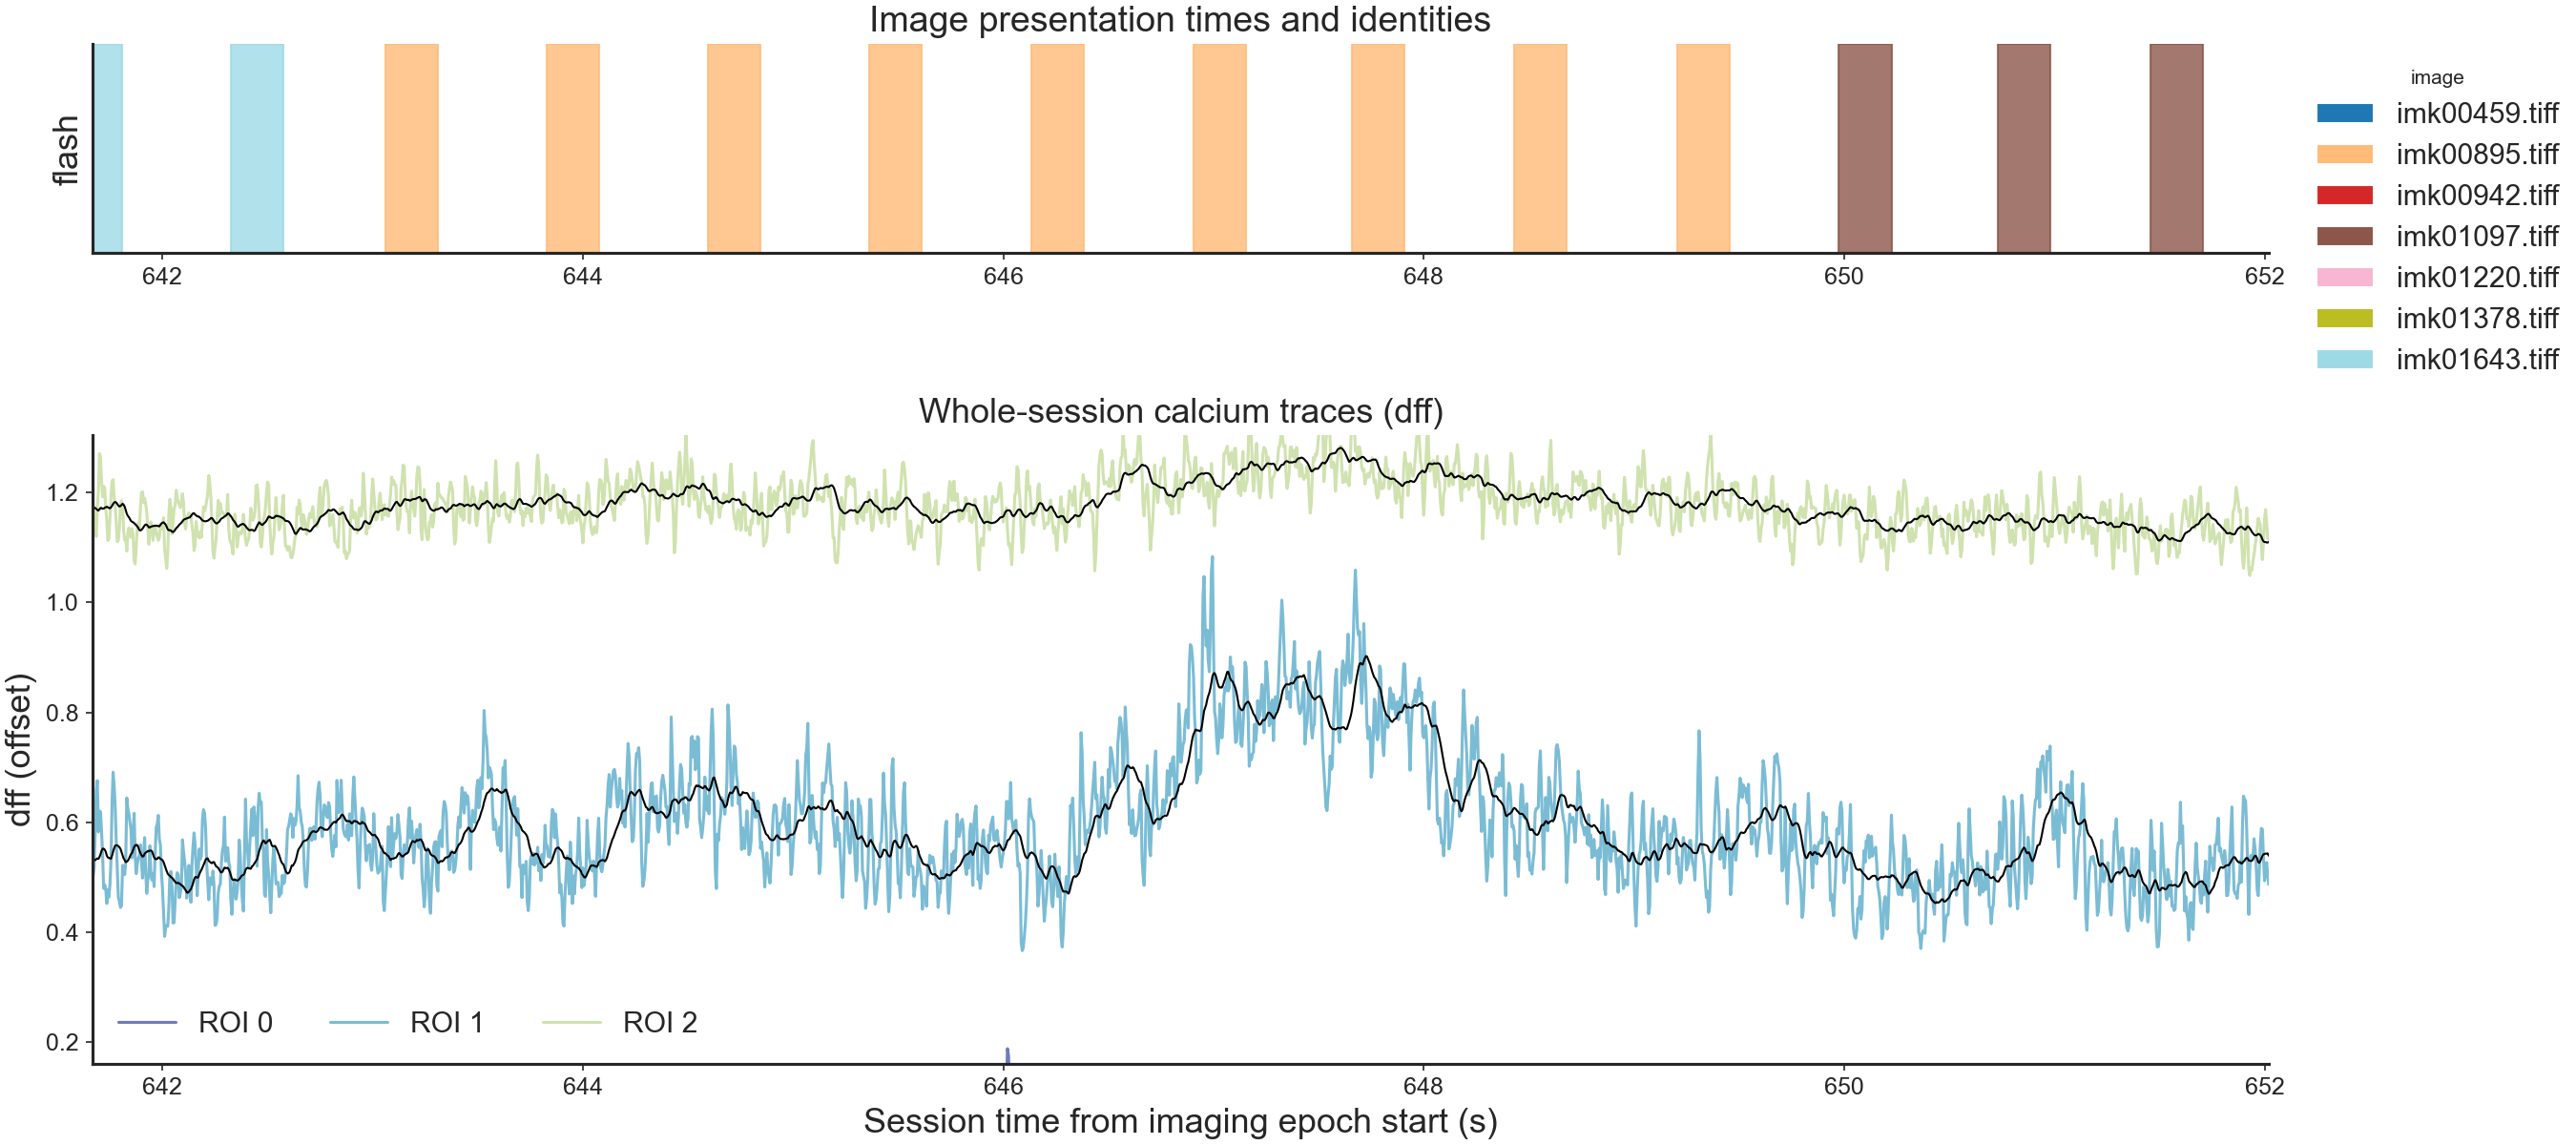

In [7]:

fig, axes = plot_whole_session_calcium(
    whole_session_ca,
    ordered_images=stim_info["ordered_images"],
    session_start_sec=stim_info["session_start_sec"],
    roi_indices=ROI_INDICES_TO_PLOT,
    trace_key=CALCIUM_TRACE_KEY,
)


<IPython.core.display.Javascript object>


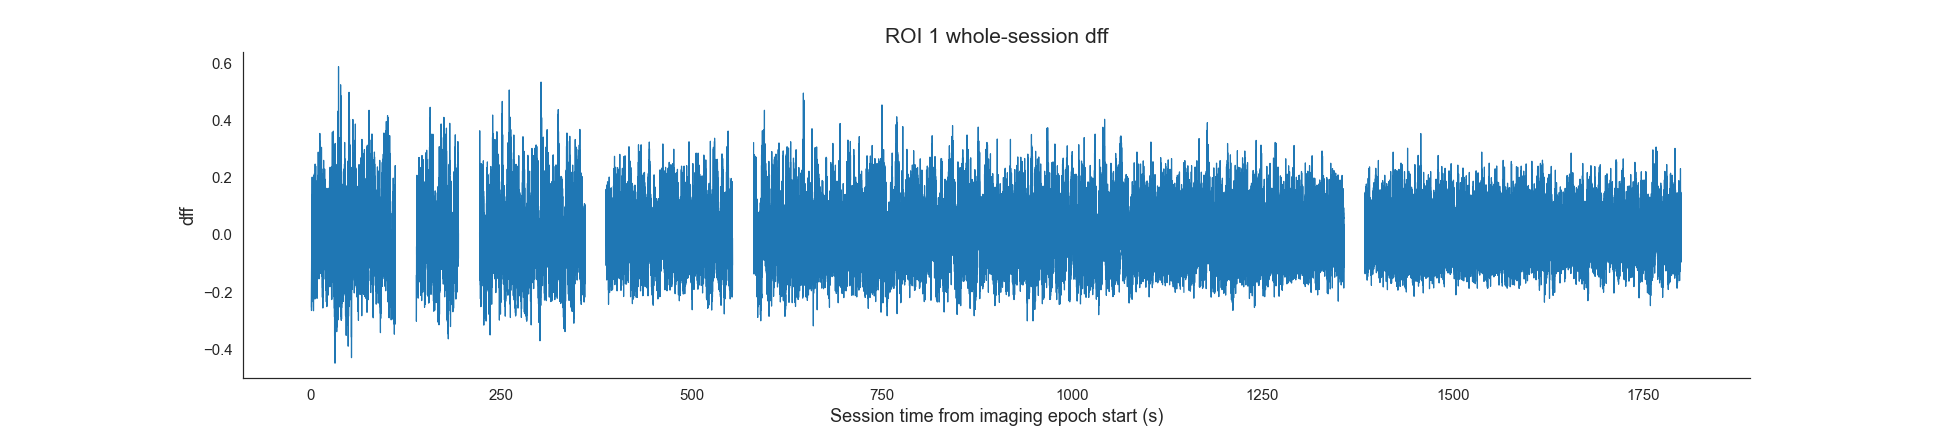

Text(0, 0.5, 'dff')

In [32]:

# Optional: inspect a single ROI more closely.
roi = ROI_INDICES_TO_PLOT[1]
time_sec = whole_session_ca["time_sec"]
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(time_sec, whole_session_ca[CALCIUM_TRACE_KEY][roi], lw=0.8)
ax.set_title(f"ROI {roi} whole-session {CALCIUM_TRACE_KEY}")
ax.set_xlabel("Session time from imaging epoch start (s)")
ax.set_ylabel(CALCIUM_TRACE_KEY)


## 2) Load extracted data and QC for glutamate and calcium

In [16]:

products = load_analysis_products(asset)
product_table = summarize_products(products)
display(product_table)


,product,exists,path
0,glutamate_qc_json,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,glutamate_qc_csv,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,glutamate_mean_npz,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,glutamate_single_npz,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,glutamate_sequence_npz,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,glutamate_meta_json,False,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,calcium_qc_json,True,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,calcium_qc_csv,True,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,calcium_mean_npz,True,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,calcium_single_npz,True,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


In [18]:

print("Glutamate extraction metadata")
pprint(products["glutamate_meta_json"])

print("Calcium extraction metadata")
pprint(products["calcium_meta_json"])


Glutamate extraction metadata
None
Calcium extraction metadata
{'epoch_duration_sec': 1800.009887999855,
 'event_counts': {'change_after_epoch_filter': 277,
                  'change_total': 278,
                  'image_after_epoch_filter': 2356,
                  'image_total': 2362,
                  'n_unique_image_ids_after_epoch_filter': 7,
                  'n_unique_image_ids_total': 7,
                  'omission_after_epoch_filter': 25,
                  'omission_total': 25},
 'indicator2': 'RCaMP3',
 'motion_correct': True,
 'per_dmd': {'DMD1': {'duration_vs_epoch_error_sec': 0.16511200014497263,
                      'image_count_by_id': {'stimuli\\images_A\\imk00459.tiff': 329,
                                            'stimuli\\images_A\\imk00895.tiff': 338,
                                            'stimuli\\images_A\\imk00942.tiff': 338,
                                            'stimuli\\images_A\\imk01097.tiff': 355,
                                            

In [19]:

if products["glutamate_qc_csv"] is not None:
    display(Markdown("### Glutamate QC table"))
    display(products["glutamate_qc_csv"].head())
else:
    print("No glutamate QC table found")

if products["calcium_qc_csv"] is not None:
    display(Markdown("### Calcium QC table"))
    display(products["calcium_qc_csv"].head())
else:
    print("No calcium QC table found")


No glutamate QC table found


### Calcium QC table

,session_id,subject_id,dmd,roi_index,roi_id,indicator2,trace_type,motion_correct,valid_trial_fraction,n_trials,...,snr_like,drift_median_diff,drift_frac,pass_finite_fraction,pass_dynamic_range,pass_abs_peak_p99,pass_snr_like,pass_abs_drift,pass_drift_frac,pass_valid_trial_fraction
0,834788_2026-03-02_10-18-42,834788,DMD1,0,DMD1_roi0000,RCaMP3,Fsvd,True,0.923077,65,...,3.336124,0.000543,0.004574,True,True,False,True,True,True,True
1,834788_2026-03-02_10-18-42,834788,DMD2,0,DMD2_roi0000,RCaMP3,Fsvd,True,0.923077,65,...,3.070592,-0.000507,0.005765,True,False,False,True,True,True,True
2,834788_2026-03-02_10-18-42,834788,DMD2,1,DMD2_roi0001,RCaMP3,Fsvd,True,0.923077,65,...,2.808048,0.002600,0.009041,True,True,True,True,True,True,True
3,834788_2026-03-02_10-18-42,834788,DMD2,2,DMD2_roi0002,RCaMP3,Fsvd,True,0.923077,65,...,2.656855,-0.000396,0.003096,True,True,False,True,True,True,True
4,834788_2026-03-02_10-18-42,834788,DMD2,3,DMD2_roi0003,RCaMP3,Fsvd,True,0.923077,65,...,2.817363,-0.000534,0.005146,True,True,False,True,True,True,True


In [21]:

# Quick inspection of extracted package structure.
for name in ["glutamate_mean_npz", "glutamate_single_npz", "glutamate_sequence_npz",
             "calcium_mean_npz", "calcium_single_npz", "calcium_sequence_npz"]:
    obj = products.get(name)
    print(f"{name}")
    if obj is None:
        print("  missing")
        continue
    if isinstance(obj, dict):
        print("  keys:", list(obj.keys()))
        for dmd_key in ["DMD1", "DMD2"]:
            if dmd_key in obj and isinstance(obj[dmd_key], dict):
                print(f"  {dmd_key} keys:", list(obj[dmd_key].keys()))
    else:
        print("  type:", type(obj))


glutamate_mean_npz
  missing
glutamate_single_npz
  missing
glutamate_sequence_npz
  missing
calcium_mean_npz
  keys: ['metadata', 'timebase_sec', 'DMD1', 'DMD2']
  DMD1 keys: ['image_identity', 'change', 'omission', 'roi_ids', 'valid_rois_mask']
  DMD2 keys: ['image_identity', 'change', 'omission', 'roi_ids', 'valid_rois_mask']
calcium_single_npz
  keys: ['metadata', 'timebase_sec', 'DMD1', 'DMD2']
  DMD1 keys: ['image_identity', 'change', 'omission', 'roi_ids', 'valid_rois_mask']
  DMD2 keys: ['image_identity', 'change', 'omission', 'roi_ids', 'valid_rois_mask']
calcium_sequence_npz
  keys: ['metadata', 'timebase_sec', 'DMD1', 'DMD2']
  DMD1 keys: ['image_identity', 'roi_ids', 'valid_rois_mask']
  DMD2 keys: ['image_identity', 'roi_ids', 'valid_rois_mask']


## 3) Display relevant meanIM for a chosen DMD

<IPython.core.display.Javascript object>


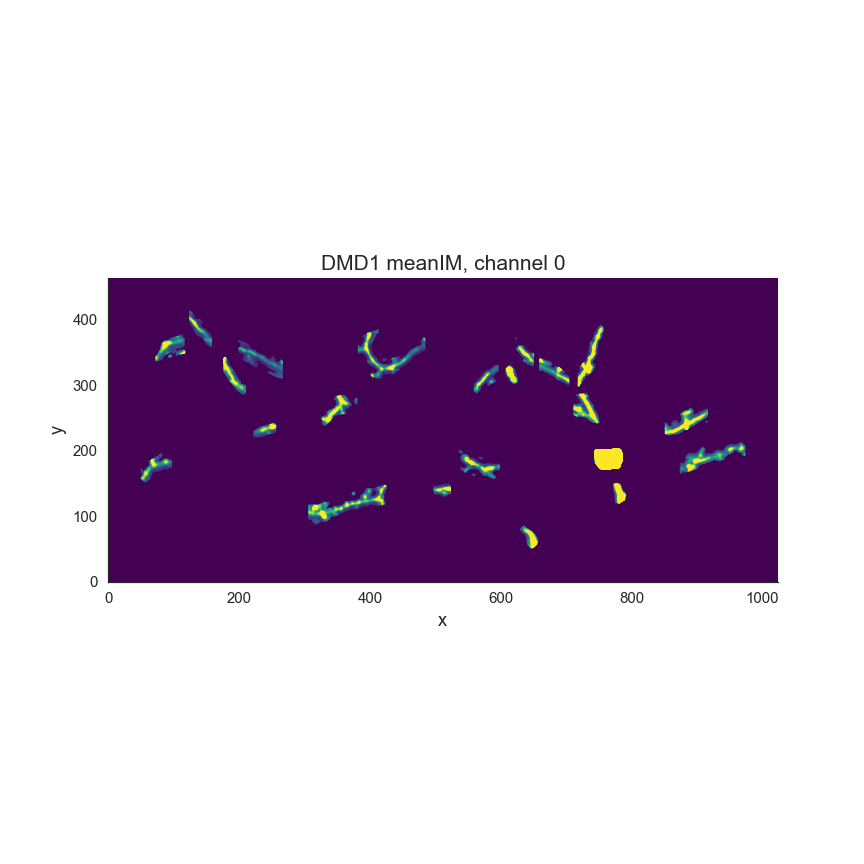

In [22]:

fig, ax = display_meanim(
    exp,
    dmd=DMD_FOR_MEANIM,
    image_type=MEANIM_IMAGE_TYPE,
    channel=MEANIM_CHANNEL,
)


<IPython.core.display.Javascript object>


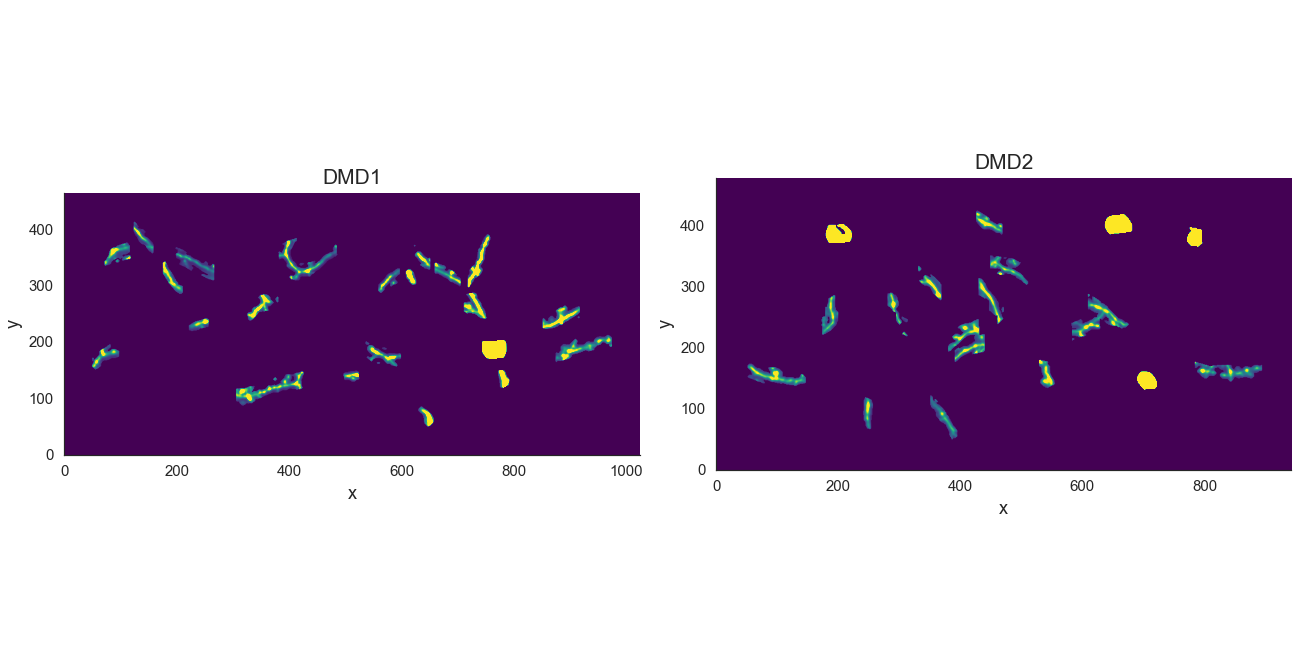

In [23]:

# Optional: compare both DMDs quickly.
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
for ax, dmd in zip(axes, [1, 2]):
    im = exp.get_summary_image(dmd=dmd, image_type=MEANIM_IMAGE_TYPE)
    im = np.asarray(im, dtype=float)
    if im.ndim == 3:
        im = im[:, MEANIM_CHANNEL, :]
    im = np.nan_to_num(im, nan=0.0)
    vmin, vmax = np.percentile(im, [1, 99])
    ax.imshow(im.T, cmap="viridis", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"DMD{dmd}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")



## Notes

- The whole-session calcium visualization uses `get_processed_soma_ca_all_trials(...)` and concatenates trials in acquisition order.
- Image flashes are drawn from the corrected Bonsai event log and, when available, filtered to the detected imaging epochs in `analysis/qc/behavior/imaging_epochs.csv`.
- The extracted product loader is read-only. It does not rerun QC or extraction.
- If a session lacks calcium outputs or manual soma ROI exports, the calcium product cells will simply show missing files.
